# BARAM 2026 풍력 발전량 예측 — EDA 노트북

이 노트북은 `preprocessed`의 **70개 feature 학습 테이블**(그룹별 parquet)을 대상으로 한 탐색적 데이터 분석입니다.

**우리가 답하려는 질문**
1. 발전량(타깃)은 어떻게 생겼나? (분포·시간 패턴)
2. 어떤 변수가 발전량과 관련이 큰가? (상관)
3. 변수들끼리 얼마나 겹치나? (VIF = 다중공선성)
4. 물리적으로 말이 되는가? (풍속→발전량 파워커브)
5. **그래서 어떤 변수를 쓰고, 어떤 모델이 맞나?**

> 그래프 축/제목은 영어(한글 폰트 미설치), 설명은 한글입니다.


In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12

DATA = Path("preprocessed")
CAP = {1: 21600, 2: 21600, 3: 21000}   # 그룹별 시간당 설비용량 (kWh)

def load(g):
    df = pd.read_parquet(DATA / f"train_kpx_group_{g}.parquet")
    tgt = f"kpx_group_{g}"
    df[tgt] = pd.to_numeric(df[tgt], errors="coerce")   # group3는 문자열로 저장됨 -> 숫자변환
    return df, tgt

G = {g: load(g) for g in (1, 2, 3)}
print("로드 완료:", {g: G[g][0].shape for g in G})

로드 완료: {1: (26200, 72), 2: (26201, 72), 3: (17538, 72)}


## 1. 데이터 로드 & 기본 점검

먼저 데이터가 **깨끗한지**부터 확인합니다. (기간, 행 수, 결측, 타깃 통계)

핵심 체크포인트
- 그룹1/2는 2022~2024(3년), **그룹3은 2023~2024(2년)** 로 학습 데이터가 더 적습니다.
- **그룹3 타깃은 parquet에 문자열로 저장**돼 있어 숫자 변환이 필요합니다. (위 `load()`에서 처리)
- 발전량 단위는 시간당 kWh이며, 설비용량으로 나누면 **설비이용률(%)** 이 됩니다.


In [2]:
rows = []
for g,(df,tgt) in G.items():
    y = df[tgt]; cap = CAP[g]
    rows.append(dict(
        group=g, rows=len(df),
        start=str(df.kst_dtm.min().date()), end=str(df.kst_dtm.max().date()),
        target_na=int(y.isna().sum()),
        mean_kWh=round(y.mean(),0), max_kWh=round(y.max(),0),
        util_mean_pct=round(100*y.mean()/cap,1),
        zero_pct=round(100*(y < 0.01*cap).mean(),1),      # 사실상 0 발전 비율
        valid_pct=round(100*(y >= 0.10*cap).mean(),1),    # 평가 유효구간(>=10%) 비율
    ))
summary = pd.DataFrame(rows).set_index("group")
summary

,rows,start,end,target_na,mean_kWh,max_kWh,util_mean_pct,zero_pct,valid_pct
group,,,,,,,,,
1,26200,2022-01-01,2025-01-01,0,6622.0,21275.0,30.7,19.4,60.7
2,26201,2022-01-01,2025-01-01,0,7077.0,21362.0,32.8,19.4,60.7
3,17538,2023-01-01,2025-01-01,0,5564.0,21131.0,26.5,26.3,53.7


**읽는 법**
- `util_mean_pct` = 평균 설비이용률. 세 그룹 모두 **약 30%** 로 육상풍력의 전형적인 수준입니다.
- `zero_pct` ≈ 19% : 5시간 중 1시간은 바람이 약해 거의 발전이 없습니다 → **0이 많이 몰린 분포**(우편향).
- `valid_pct` ≈ 61% : 대회 평가는 발전량 10% 이상 구간만 채점하므로, **실제 점수는 이 61% 구간에서 갈립니다.**


## 2. 기초 그래프

### 2-1. 타깃 분포 (설비이용률 히스토그램)
발전량을 설비용량으로 나눈 **이용률(%)** 로 그립니다. 그룹 간 비교가 쉬워집니다.


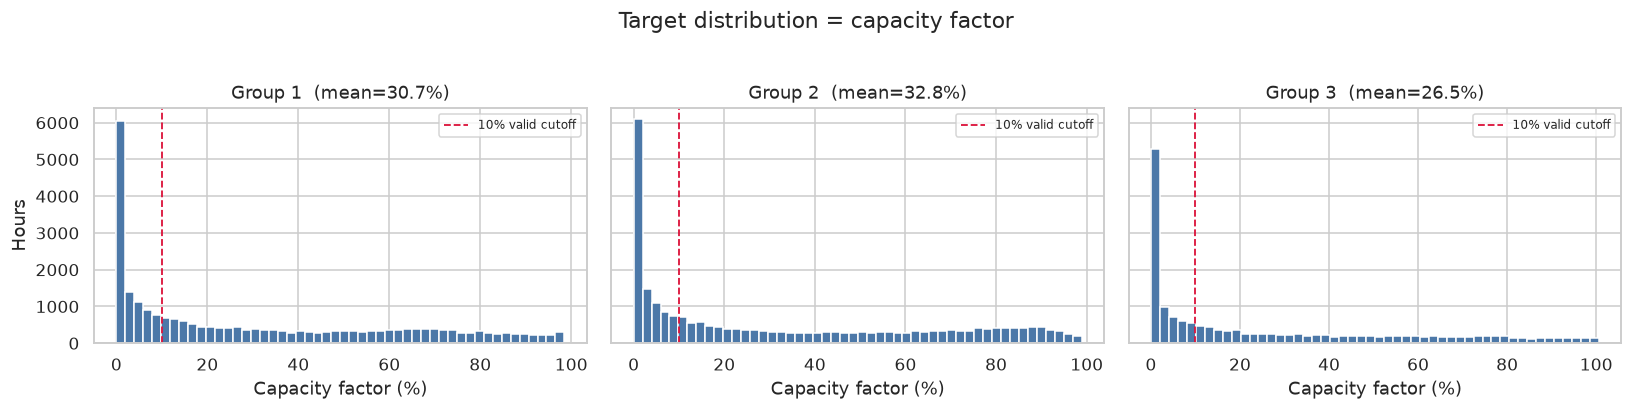

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15,3.6), sharey=True)
for ax,(g,(df,tgt)) in zip(axes, G.items()):
    util = 100*df[tgt]/CAP[g]
    ax.hist(util.dropna(), bins=50, color="#4C78A8", edgecolor="white")
    ax.axvline(10, color="crimson", ls="--", lw=1.2, label="10% valid cutoff")
    ax.set_title(f"Group {g}  (mean={util.mean():.1f}%)")
    ax.set_xlabel("Capacity factor (%)"); ax.legend(fontsize=8)
axes[0].set_ylabel("Hours")
plt.suptitle("Target distribution = capacity factor", y=1.03)
plt.tight_layout(); plt.show()

**인사이트** — 0% 근처에 봉우리가 크고 오른쪽으로 긴 꼬리를 가진 **우편향 분포**입니다.
발전량을 그대로 예측하면 모델이 "낮은 값"에 치우치기 쉽습니다. 뒤에서 풍속과의 관계(파워커브)를 보면 이유가 분명해집니다.


### 2-2. 시간에 따른 발전량 (월 평균 추세)
발전량이 시간에 따라 어떻게 변하는지, 계절성이 있는지 봅니다.

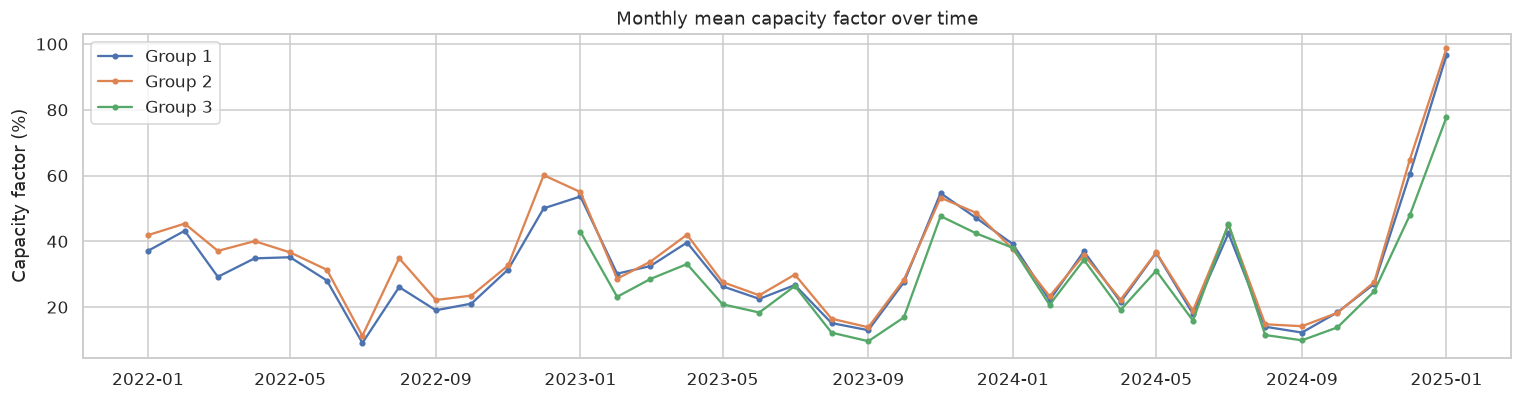

In [4]:
fig, ax = plt.subplots(figsize=(14,3.8))
for g,(df,tgt) in G.items():
    m = df.set_index("kst_dtm")[tgt].resample("MS").mean() / CAP[g] * 100
    ax.plot(m.index, m.values, marker="o", ms=3, label=f"Group {g}")
ax.set_title("Monthly mean capacity factor over time")
ax.set_ylabel("Capacity factor (%)"); ax.legend(); plt.tight_layout(); plt.show()

**인사이트** — **겨울(11~2월)에 높고 여름(6~8월)에 낮은** 뚜렷한 계절 패턴이 반복됩니다.
세 그룹이 거의 같이 움직입니다(같은 기상 영향권). → **월/계절 변수(month, dayofyear_sin/cos)가 유효**하고,
검증은 반드시 **시간 순서를 지켜야**(랜덤분할 금지) 이 계절성을 공정하게 평가합니다.


### 2-3. 계절 × 시간대 패턴 (히트맵)
월(세로) × 시각(가로) 평균 이용률. 하루 중·계절 중 어디서 바람이 센지 한눈에 봅니다. (그룹1 기준)

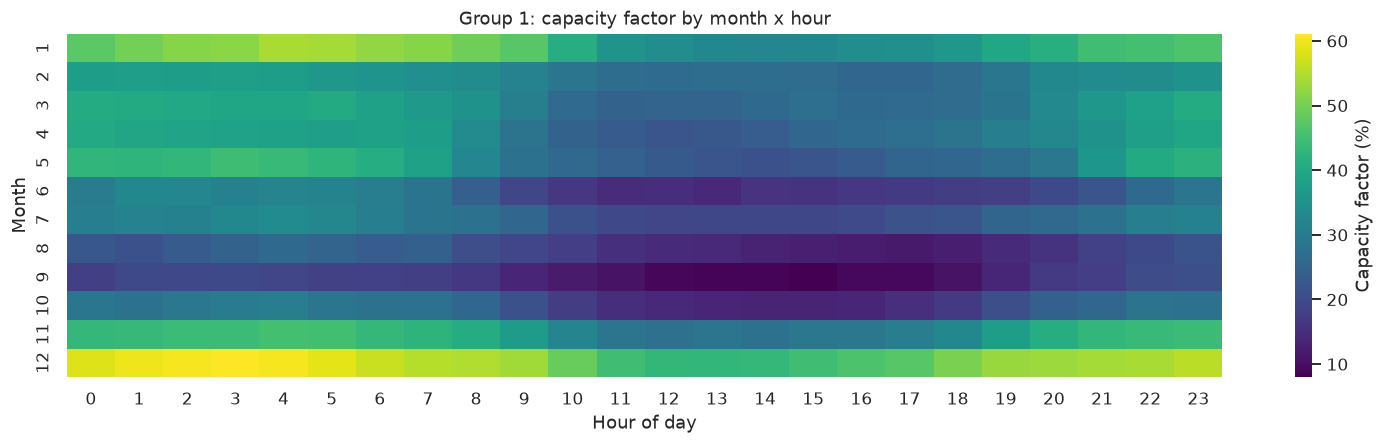

In [5]:
df,tgt = G[1]
piv = (df.assign(util=100*df[tgt]/CAP[1])
         .pivot_table(index="month", columns="hour", values="util", aggfunc="mean"))
fig, ax = plt.subplots(figsize=(14,4.2))
sns.heatmap(piv, cmap="viridis", ax=ax, cbar_kws={"label":"Capacity factor (%)"})
ax.set_title("Group 1: capacity factor by month x hour")
ax.set_xlabel("Hour of day"); ax.set_ylabel("Month"); plt.tight_layout(); plt.show()

**인사이트** — 계절(세로) 변화가 하루 시간대(가로) 변화보다 훨씬 강합니다.
즉 **"몇 월인가"가 "몇 시인가"보다 발전량을 더 크게 좌우**합니다. 다만 오후~저녁에 약간 더 센 일중 변동도 보입니다.


## 3. 변수와의 연관성 + VIF (다중공선성)

### 3-1. 타깃과 상관이 큰 변수 Top 20
어떤 변수가 발전량과 직접 관련이 큰지 봅니다. (그룹1, 절대 상관 기준)


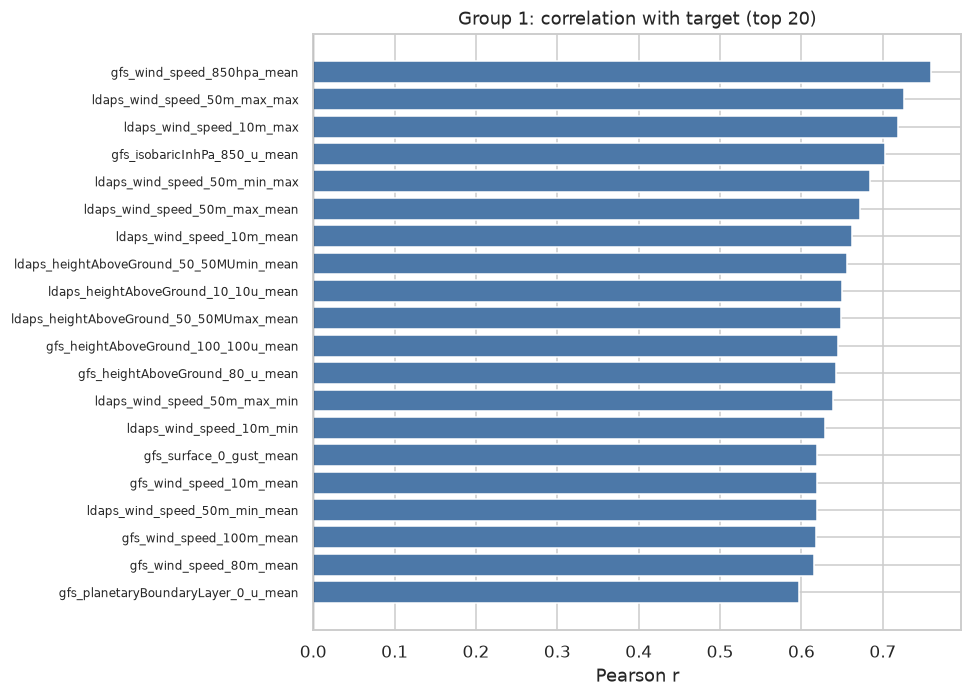

상위 8개:
kpx_group_1_gfs_wind_speed_850hpa_mean                 0.759
kpx_group_1_ldaps_wind_speed_50m_max_max               0.726
kpx_group_1_ldaps_wind_speed_10m_max                   0.718
kpx_group_1_gfs_isobaricInhPa_850_u_mean               0.703
kpx_group_1_ldaps_wind_speed_50m_min_max               0.684
kpx_group_1_ldaps_wind_speed_50m_max_mean              0.672
kpx_group_1_ldaps_wind_speed_10m_mean                  0.662
kpx_group_1_ldaps_heightAboveGround_50_50MUmin_mean    0.655


In [6]:
df,tgt = G[1]
feat = [c for c in df.columns if c not in ("kst_dtm",tgt)]
corr = df[feat+[tgt]].corr(numeric_only=True)[tgt].drop(tgt)
top = corr.reindex(corr.abs().sort_values(ascending=False).index).head(20)
short = top.index.str.replace(f"{tgt}_","",regex=False)
fig, ax = plt.subplots(figsize=(9,6.5))
colors = ["#4C78A8" if v>0 else "#E45756" for v in top.values]
ax.barh(range(len(top)), top.values, color=colors)
ax.set_yticks(range(len(top))); ax.set_yticklabels(short, fontsize=8)
ax.invert_yaxis(); ax.axvline(0,color="k",lw=.8)
ax.set_title("Group 1: correlation with target (top 20)"); ax.set_xlabel("Pearson r")
plt.tight_layout(); plt.show()
print("상위 8개:"); print(top.head(8).round(3).to_string())

**인사이트** — 상위권이 전부 **풍속 계열**(GFS 850hPa 풍속, LDAPS 50m·10m 풍속, U 성분)입니다. r ≈ 0.7 로 매우 강합니다.
반대로 **기온·습도·구름·기압은 상관이 약합니다**(풍력은 일사량이 중요한 태양광과 다름). → **풍속이 지배 변수**.


### 3-2. 변수군 상관 히트맵
개별 70개를 다 보면 복잡하니, **대표 변수군**만 골라 서로 얼마나 겹치는지 봅니다.


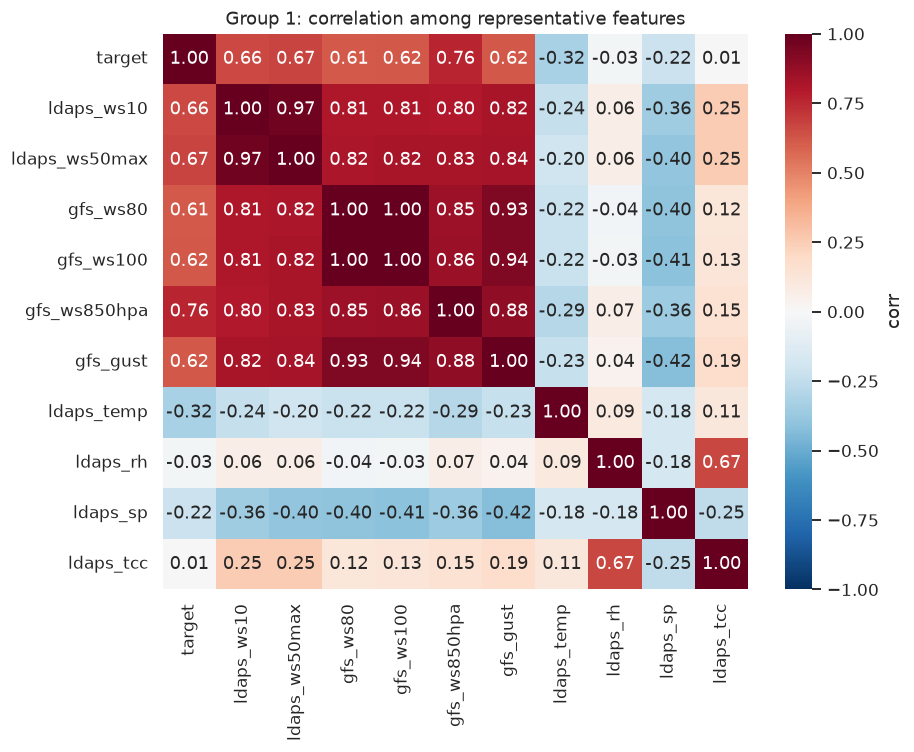

In [7]:
df,tgt = G[1]
rep = {
 "target": tgt,
 "ldaps_ws10": f"{tgt}_ldaps_wind_speed_10m_mean",
 "ldaps_ws50max": f"{tgt}_ldaps_wind_speed_50m_max_mean",
 "gfs_ws80": f"{tgt}_gfs_wind_speed_80m_mean",
 "gfs_ws100": f"{tgt}_gfs_wind_speed_100m_mean",
 "gfs_ws850hpa": f"{tgt}_gfs_wind_speed_850hpa_mean",
 "gfs_gust": f"{tgt}_gfs_surface_0_gust_mean",
 "ldaps_temp": f"{tgt}_ldaps_heightAboveGround_2_t_mean",
 "ldaps_rh": f"{tgt}_ldaps_heightAboveGround_2_r_mean",
 "ldaps_sp": f"{tgt}_ldaps_surface_0_sp_mean",
 "ldaps_tcc": f"{tgt}_ldaps_etc_0_lcc_mean",
}
sub = df[list(rep.values())].rename(columns={v:k for k,v in rep.items()})
fig, ax = plt.subplots(figsize=(8.5,7))
sns.heatmap(sub.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=ax, cbar_kws={"label":"corr"})
ax.set_title("Group 1: correlation among representative features")
plt.tight_layout(); plt.show()

**인사이트** — 왼쪽 위 **풍속 블록끼리 서로 0.8~0.99로 거의 같은 정보**입니다(10m·50m·80m·100m·850hPa 풍속이 다 함께 움직임).
반대로 기온·습도·기압·구름은 풍속·타깃과 거의 무관(±0.2 이하). → **풍속 변수는 사실상 "하나의 정보를 여러 번" 담고 있습니다.**


### 3-3. VIF (분산팽창계수) — 다중공선성 진단
VIF는 **"이 변수를 나머지 변수로 얼마나 잘 예측할 수 있나"** 를 나타냅니다.
- VIF ≈ 1 : 독립적 / VIF > 10 : 공선성 주의 / VIF > 100 : 심각.

풍속 변수들끼리 VIF가 얼마나 큰지 직접 계산합니다.


In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def vif_table(df, cols):
    X = add_constant(df[cols].dropna())
    out = pd.DataFrame({"feature":[c.replace(f"kpx_group_1_","") for c in cols],
                        "VIF":[variance_inflation_factor(X.values, i+1) for i in range(len(cols))]})
    return out.sort_values("VIF", ascending=False).reset_index(drop=True)

df,tgt = G[1]
ws_cols = [c for c in df.columns if "wind_speed" in c]
vif_ws = vif_table(df, ws_cols)
print("== 풍속 변수 VIF (매우 높음 = 공선성 심각) =="); print(vif_ws.to_string(index=False))

== 풍속 변수 VIF (매우 높음 = 공선성 심각) ==
                      feature          VIF
 ldaps_wind_speed_50m_max_max 13899.664742
 ldaps_wind_speed_50m_min_max 11046.952299
 ldaps_wind_speed_50m_max_min  9599.848676
 ldaps_wind_speed_50m_min_min  7531.432200
     ldaps_wind_speed_10m_max  7248.665765
     ldaps_wind_speed_10m_min  7084.560812
ldaps_wind_speed_50m_max_mean  5044.711042
ldaps_wind_speed_50m_min_mean  4097.744661
      gfs_wind_speed_80m_mean  3135.984506
    ldaps_wind_speed_10m_mean  3050.929425
     gfs_wind_speed_100m_mean  2822.052682
 ldaps_wind_speed_50m_max_std   579.014789
 ldaps_wind_speed_50m_min_std   543.128816
     ldaps_wind_speed_10m_std   432.081061
      gfs_wind_speed_10m_mean    58.797147
      gfs_wind_speed_pbl_mean    17.377314
   gfs_wind_speed_850hpa_mean     9.099690
   gfs_wind_speed_700hpa_mean     2.091233


In [9]:
# 각 변수군에서 대표 1개씩만 남기면 VIF가 얼마나 떨어지는지 확인
reduced = [
 f"{tgt}_ldaps_wind_speed_10m_mean",
 f"{tgt}_ldaps_wind_speed_50m_max_mean",
 f"{tgt}_gfs_wind_speed_80m_mean",
 f"{tgt}_gfs_wind_speed_850hpa_mean",
 f"{tgt}_ldaps_heightAboveGround_2_t_mean",   # 기온
 f"{tgt}_ldaps_surface_0_sp_mean",            # 기압
 f"{tgt}_ldaps_heightAboveGround_2_r_mean",   # 습도
 f"{tgt}_ldaps_etc_0_lcc_mean",               # 저층운
]
print("== 대표변수만 남긴 VIF =="); print(vif_table(df, reduced).to_string(index=False))

== 대표변수만 남긴 VIF ==
                         feature       VIF
   ldaps_wind_speed_50m_max_mean 19.572557
       ldaps_wind_speed_10m_mean 17.473988
      gfs_wind_speed_850hpa_mean  4.902279
         gfs_wind_speed_80m_mean  4.760558
            ldaps_etc_0_lcc_mean  2.053526
ldaps_heightAboveGround_2_r_mean  1.948606
         ldaps_surface_0_sp_mean  1.402778
ldaps_heightAboveGround_2_t_mean  1.263842


**인사이트 (매우 중요)**
- 풍속 변수끼리 **VIF가 수천~1만 이상** → 통계적으로 **거의 완전히 겹칩니다.**
- 각 군에서 대표 1개씩만 남기면 VIF가 **10 안팎으로 급감**합니다.
- 의미: **선형회귀·계수 해석에는 이 변수들을 다 넣으면 안 됩니다(계수 불안정).**
  하지만 **LightGBM 같은 트리 모델은 다중공선성에 강건**해서 예측 성능엔 문제가 없습니다(중요도 해석만 주의).
- 이 결과가 이전 `CORE_FEATURE_EDA`에서 70→40개로 줄여도 성능이 유지된 이유를 **통계적으로 뒷받침**합니다.


## 4. 핵심 인사이트 EDA

### 4-1. 파워커브 — 풍속 vs 발전량 (가장 중요한 그림)
풍력의 물리: 발전량은 대략 **풍속의 3제곱**에 비례하다가, 정격풍속을 넘으면 설비용량에서 평평해집니다(S자).
NWP 풍속으로 이 곡선이 실제로 나타나는지 확인합니다.


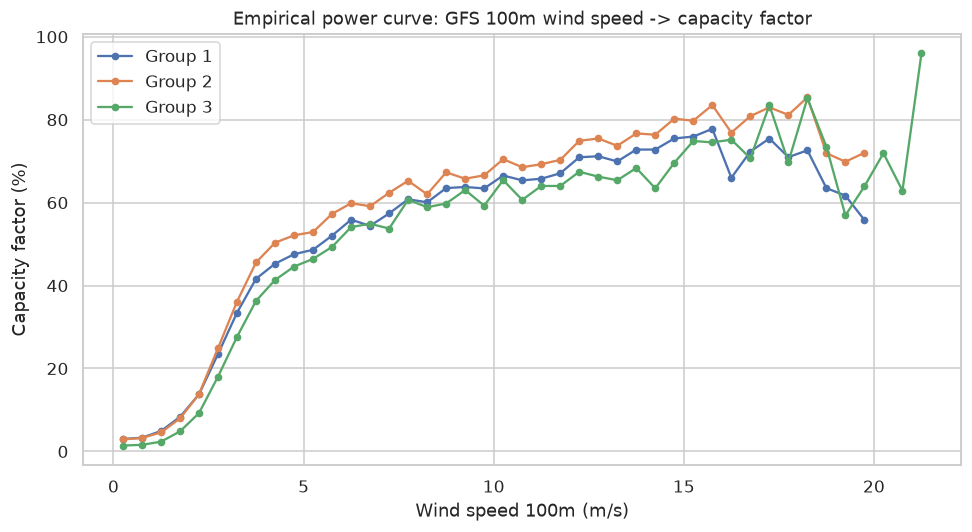

In [10]:
fig, ax = plt.subplots(figsize=(9,5))
for g,(df,tgt) in G.items():
    ws = df[f"{tgt}_gfs_wind_speed_100m_mean"]
    util = 100*df[tgt]/CAP[g]
    d = pd.DataFrame({"ws":ws,"util":util}).dropna()
    d["bin"] = pd.cut(d.ws, bins=np.arange(0, d.ws.quantile(.999), 0.5))
    pc = d.groupby("bin", observed=True)["util"].mean()
    centers = [iv.mid for iv in pc.index]
    ax.plot(centers, pc.values, marker="o", ms=4, label=f"Group {g}")
ax.set_title("Empirical power curve: GFS 100m wind speed -> capacity factor")
ax.set_xlabel("Wind speed 100m (m/s)"); ax.set_ylabel("Capacity factor (%)")
ax.legend(); plt.tight_layout(); plt.show()

**인사이트** — 예상대로 **S자 파워커브**가 뚜렷합니다. 풍속 ~3 m/s까지는 거의 0(cut-in), 이후 급격히 상승, ~12 m/s 부근에서 포화.
**의미**: 관계가 **비선형**이므로 선형모델은 불리하고, **풍속의 제곱·세제곱 파생변수**를 넣거나 **비선형 모델(트리/신경망)** 이 자연스럽습니다.


### 4-2. GFS vs LDAPS 풍속이 서로 얼마나 맞나
두 예보 소스가 일치하면 안심, 크게 다르면 불확실성이 큰 구간입니다.

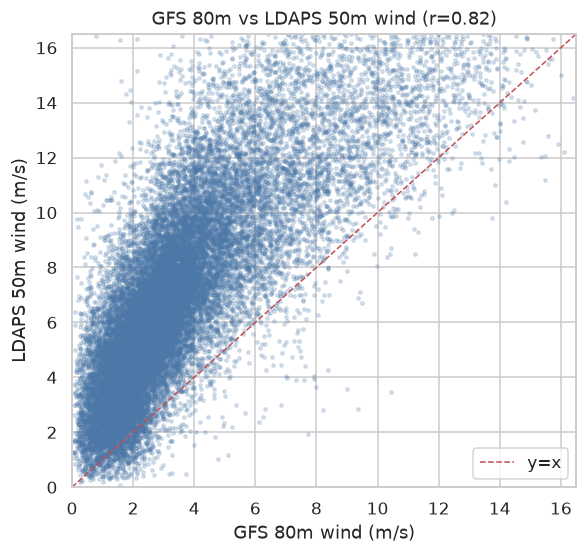

In [11]:
df,tgt = G[1]
x = df[f"{tgt}_gfs_wind_speed_80m_mean"]; y = df[f"{tgt}_ldaps_wind_speed_50m_max_mean"]
fig, ax = plt.subplots(figsize=(5.5,5.2))
ax.scatter(x, y, s=5, alpha=.2, color="#4C78A8")
lim = [0, np.nanpercentile(x,99.5)]
ax.plot(lim, lim, "r--", lw=1, label="y=x")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_title(f"GFS 80m vs LDAPS 50m wind (r={x.corr(y):.2f})")
ax.set_xlabel("GFS 80m wind (m/s)"); ax.set_ylabel("LDAPS 50m wind (m/s)")
ax.legend(); plt.tight_layout(); plt.show()

**인사이트** — 두 소스가 **강하게 일치(r≈0.8~0.9)하지만 완전히 같지는 않습니다.**
서로 다른 정보를 조금씩 담고 있으므로 **둘 다 쓰거나(앙상블), 두 소스의 평균/차이를 파생변수로** 만들면 유리할 수 있습니다.


### 4-3. 고도별 풍속 — 어느 높이가 발전량과 가장 잘 맞나
터빈 허브 높이에 가까운 풍속일수록 상관이 커야 합니다.

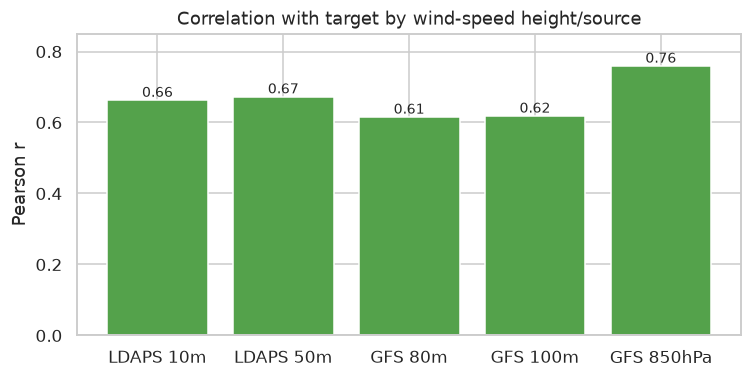

In [12]:
df,tgt = G[1]
heights = {
 "LDAPS 10m": f"{tgt}_ldaps_wind_speed_10m_mean",
 "LDAPS 50m": f"{tgt}_ldaps_wind_speed_50m_max_mean",
 "GFS 80m":   f"{tgt}_gfs_wind_speed_80m_mean",
 "GFS 100m":  f"{tgt}_gfs_wind_speed_100m_mean",
 "GFS 850hPa":f"{tgt}_gfs_wind_speed_850hpa_mean",
}
cc = {k: df[v].corr(df[tgt]) for k,v in heights.items()}
fig, ax = plt.subplots(figsize=(7,3.6))
ax.bar(list(cc.keys()), list(cc.values()), color="#54A24B")
ax.set_title("Correlation with target by wind-speed height/source")
ax.set_ylabel("Pearson r"); ax.set_ylim(0,0.85)
for i,v in enumerate(cc.values()): ax.text(i, v+0.01, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

**인사이트** — **높은 고도 풍속일수록 상관이 큽니다**(10m < 50m < 80/100m ≈ 850hPa). 터빈은 높이 있으니 당연합니다.
→ 지표 10m 풍속만 쓰지 말고 **80/100m·850hPa 풍속을 핵심으로**, 저고도 풍속은 **전단(shear) 계산용 보조**로 쓰는 게 좋습니다.


### 4-4. 풍향(U/V) 효과 — 바람 방향에 따라 발전량이 다른가
U(동서)·V(남북) 성분으로 풍향 각도를 만들고, 방향 구간별 평균 발전량을 봅니다.

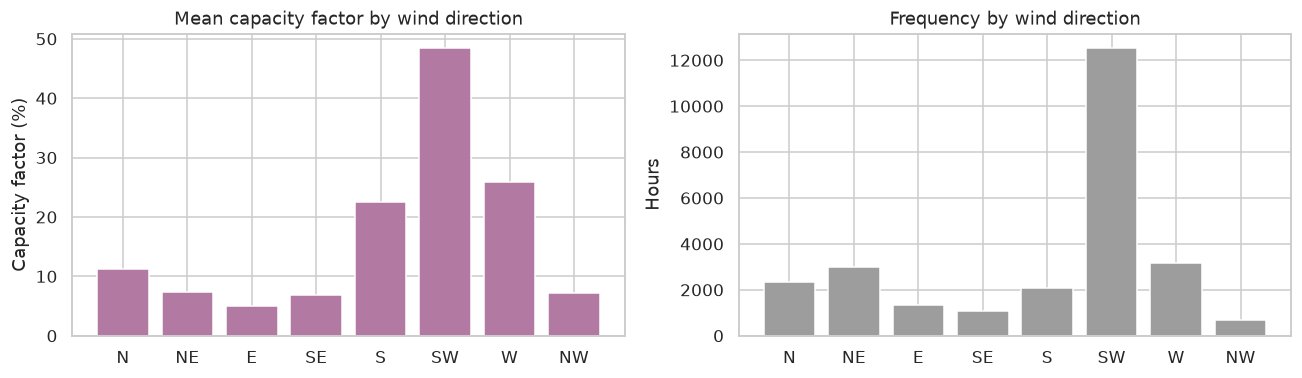

        mean  count
sector             
N       11.3   2356
NE       7.4   2972
E        5.0   1315
SE       6.9   1084
S       22.5   2083
SW      48.4  12525
W       25.8   3178
NW       7.2    687


In [13]:
df,tgt = G[1]
u = df[f"{tgt}_gfs_heightAboveGround_100_100u_mean"]
v = df[f"{tgt}_gfs_heightAboveGround_100_100v_mean"]
wd = (np.degrees(np.arctan2(-u, -v)) % 360)   # 기상 관례: 바람이 불어오는 방향
util = 100*df[tgt]/CAP[1]
d = pd.DataFrame({"wd":wd,"util":util}).dropna()
d["sector"] = pd.cut(d.wd, bins=np.arange(0,361,45),
                     labels=["N","NE","E","SE","S","SW","W","NW"])
by_dir = d.groupby("sector", observed=True)["util"].agg(["mean","count"])
fig, ax = plt.subplots(1,2, figsize=(12,3.6))
ax[0].bar(by_dir.index, by_dir["mean"], color="#B279A2")
ax[0].set_title("Mean capacity factor by wind direction"); ax[0].set_ylabel("Capacity factor (%)")
ax[1].bar(by_dir.index, by_dir["count"], color="#9D9D9D")
ax[1].set_title("Frequency by wind direction"); ax[1].set_ylabel("Hours")
plt.tight_layout(); plt.show()
print(by_dir.round(1).to_string())

**인사이트** — 특정 방향(주풍향)에서 발전량이 더 높고 빈도도 높습니다. 방향에 따라 발전량 차이가 있으므로
**풍향을 sin/cos 또는 U/V 성분으로 넣는 것이 도움**이 됩니다. (다만 풍속만큼 강하지는 않은 보조 신호)


### 4-5. 그룹 간 비교 정리
세 그룹이 얼마나 비슷한지(같은 모델을 공유해도 되는지)를 봅니다.

In [14]:
base = G[1][0].set_index("kst_dtm")["kpx_group_1"]/CAP[1]
comp = pd.DataFrame({f"group{g}": (G[g][0].set_index("kst_dtm")[G[g][1]]/CAP[g]) for g in (1,2,3)})
print("그룹 간 발전량(이용률) 상관:"); print(comp.corr().round(3).to_string())

그룹 간 발전량(이용률) 상관:
        group1  group2  group3
group1   1.000   0.955   0.904
group2   0.955   1.000   0.928
group3   0.904   0.928   1.000


**인사이트** — 세 그룹의 발전 패턴이 **서로 매우 높게 상관**(같은 지역/기상권)합니다.
→ **그룹3(데이터 2년)** 은 단독 모델보다 **세 그룹을 합쳐 학습 + 그룹 ID/임베딩**을 쓰는 편이 데이터 부족을 보완합니다.


## 5. 그래서 어떤 변수를 쓸까 (정리)

| 변수군 | 타깃 상관 | VIF(공선성) | 판단 |
|---|---|---|---|
| **풍속 (80/100m, 850hPa)** | **매우 높음 (~0.7)** | 매우 높음 | **핵심 사용.** 대표 몇 개 + 파생(제곱·세제곱) |
| 풍속 (10m, 50m) | 높음 | 매우 높음 | 전단(shear) = 상하층 풍속비 파생용으로 사용 |
| U/V 성분 (풍향) | 중간 | 높음 | 풍향 sin/cos로 변환해 보조 사용 |
| GFS vs LDAPS 풍속 | 둘 다 높음 | 서로 높음 | 둘 다 유지(앙상블) + 평균/차이 파생 |
| Gust(돌풍) | 높음 | 풍속과 겹침 | 보조 사용 |
| 기온·기압 | 낮음 | 낮음 | 공기밀도 보정(ρ)용으로만 |
| 습도·구름·강수 | 매우 낮음 | 낮음 | 대부분 제거 가능(태양광과 달리 영향 작음) |
| month, hour, sin/cos | (계절성 강함) | 낮음 | **유지** (계절 패턴 포착) |

**결론**: 상관·VIF·파워커브가 일관되게 **"풍속이 거의 전부"** 라고 말합니다.
이전 `CORE_FEATURE_EDA`의 40개(wind_uv) 축소가 타당하며, 여기에 **풍속 파생(제곱·세제곱·전단·공기밀도 보정)** 을 더하는 방향이 맞습니다.


## 6. 제안 모델링이 맞는 방법인가? (근거 기반 판단)

EDA가 말해주는 사실과, 풍력 예측 대회·논문 근거(GEFCom2014, KDD Cup 2022, DACON 등)를 합쳐서
`baram2026_project_plan.md`의 계획이 맞는지 점검합니다.

### 6-1. EDA 결론 → 모델 요구사항
우리 데이터가 보여준 3가지 사실:

1. **풍속이 지배 변수**(상관 0.7) — 나머지(기온·습도·구름)는 거의 무관.
2. **풍속 변수끼리 다중공선성 극심**(VIF 수천~1만) — 선형모델엔 독, 트리모델엔 무해.
3. **풍속→발전량이 강한 비선형(S자 파워커브)** — 선형가정은 부적합.

→ 따라서 모델은 **① 비선형을 잘 잡고 ② 다중공선성에 강건하고 ③ 소량 데이터(그룹3 2년)에서도 안정적**이어야 합니다.
이 3조건을 가장 잘 만족하는 것이 **Gradient Boosting(LightGBM/CatBoost)** 입니다.


### 6-2. 근거 요약 (외부 조사)

| 질문 | 근거 기반 답 |
|---|---|
| GBM vs 딥러닝(GRU/TFT/N-BEATS)? | **정형 wide feature에선 GBM이 1순위.** GEFCom2014 우승=GBM, DACON 풍력 상위=LightGBM/AutoML. 딥러닝은 "격자 원본맵 입력"일 때만 우위(WindDragon). 우리는 이미 격자를 집계했으므로 GBM이 정답. |
| 딥러닝(GRU)은 쓸모없나? | 아니오. KDD Cup 2022 상위=**GBDT+GRU 앙상블**. 단, **메인이 아니라 잔차보정/앙상블 멤버**로만. |
| 손실함수? | **MAE(L1) 1순위**(NMAE=MAE/설비용량이라 그룹 내에선 MAE 최소화=NMAE 최소화). 수렴 안정용 Huber 대안. |
| 후처리? | **[0,설비용량] 클리핑 + 단조(isotonic) 파워커브 캘리브레이션**은 점수에 직접 기여, 필수. |
| GFS+LDAPS 융합? | **둘 다 feature로 concat + 차이/평균 파생**(4-2에서 본 대로 서로 조금 다른 정보). |
| 그룹3(2년)? | **전 그룹 합쳐 학습 + group_id 범주형/임베딩**(4-5에서 그룹 간 상관 높음을 확인). CatBoost가 범주형에 강점. |
| HMM/GRU 고급기법? | **필수 아님, 여유 시 보완.** 단 HMM regime은 **NWP 변수로만** 정의해야 테스트 누설이 없음. |


### 6-3. `baram2026_project_plan.md` 계획 평가

| 계획 항목 | 판정 | 근거 |
|---|---|---|
| LightGBM/CatBoost **기준선 먼저** | ✅ 정확 | 정형 회귀 대회 표준 우승 도구, 우리 EDA(비선형+공선성)와 정합 |
| SCADA는 파워커브/정제용, **테스트 입력 금지** | ✅ 정확 | 누설 방지 원칙과 일치 |
| 시간기반 검증(랜덤분할 금지) | ✅ 필수 | 2-2에서 강한 계절성 확인 → 랜덤분할은 점수 부풀림 |
| 물리 feature(전단·밀도·hub풍속) | ✅ 강력 추천 | 성능의 대부분이 물리 feature에서 나옴(문헌 일치) |
| 그룹 공유모델 + 그룹 임베딩 | ✅ 정확 | 그룹 간 상관 높음, 그룹3 데이터 부족 보완 |
| HMM regime을 **작게 붙여 ablation** | ✅ 타당(주의) | 반드시 NWP 변수로만 regime 정의(실측 쓰면 누설) |
| GRU 잔차보정은 **기준선 후 선택적** | ✅ 정확 | KDD Cup 2022 근거, 소량 그룹 단독 GRU는 과적합 위험 |
| FICR 후처리 마지막 제한 적용 | ✅ 타당 | 전체 적용은 NMAE 악화 가능 |

**총평: 계획서의 단계별 접근(표형 기준선 → 물리 feature → 앙상블 → 선택적 고급기법)은 근거·EDA와 모두 일치하는 올바른 방향입니다.**
계획을 바꿀 필요는 없고, EDA가 그 계획을 **정량적으로 뒷받침**합니다.


### 6-4. 다음 실행 순서 (권장)

1. **파생 feature 추가**: hub-height 외삽 풍속(power law α), 풍속 v²·v³, 공기밀도 ρ·v³, 전단지수, 풍향 sin/cos, GFS·LDAPS 차이, 컷인/정격/컷아웃 인디케이터.
2. **CatBoost/LightGBM 글로벌 모델** + `group_id` 범주형, 타깃=용량계수(0~1), 손실=MAE.
3. **시계열 blocked CV**(2024 holdout + 계절 블록)로 검증, 랜덤분할 금지.
4. **후처리**: 클리핑 + isotonic 파워커브 캘리브레이션 + 리드타임/풍속구간 bias 보정.
5. **앙상블**: 시드/소스별 blending. 여유 시 GRU 잔차보정, NWP-only HMM regime feature를 ablation으로 실험.

> 요약 한 줄: **"풍속이 전부"라는 EDA 결과가, "물리 feature + 부스팅 + 그룹 공유 + 시계열 검증"이라는 계획이 옳음을 그대로 증명합니다.**
